In [109]:
%pylab inline
%load_ext autoreload
%autoreload 2
import scipy.io.wavfile

Populating the interactive namespace from numpy and matplotlib
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
!head 12076.txt

*1000Hz	-41.0
	
20.00	-2.7
20.55	-2.7
21.11	-2.6
21.69	-2.5
22.29	-2.5
22.90	-2.4
23.53	-2.3
24.18	-2.1


In [3]:
first_line = open('12076.txt').readline()
db_offset = float(first_line.split()[1])
df = pd.read_table('12076.txt', names=['hz', 'db'], skiprows=2)
df = df.set_index('hz')
df.db = df.db + db_offset

In [4]:
df.head()

,db
hz,
20.00,-43.7
20.55,-43.7
21.11,-43.6
21.69,-43.5
22.29,-43.5


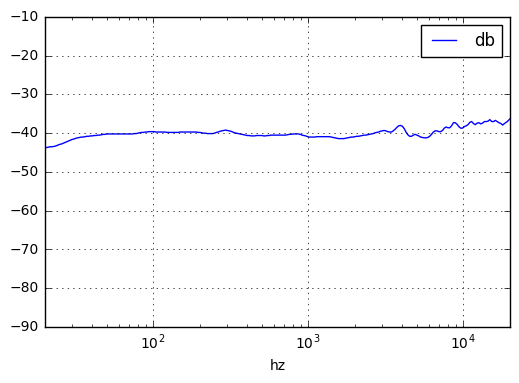

In [5]:
df.plot(grid=True, logx=True, ylim=[-90, -10])

In [6]:
# $ arecord -f U24_LE -c 2 -r 192000
# didn't work
# arecord -f S24_LE -c 2 -r 192000 > out.wav
# scipy.io.wavfile.read('/home/brandon/out.wav')
# ValueError: Unsupported bit depth: the wav file has 24-bit data.
# arecord -f S32_LE -c 2 -r 192000 > out.wav
# scipy.io.wavfile.read('/home/brandon/out.wav')
# WavFileWarning: Chunk (non-data) not understood, skipping it.
# 100% cpu and lost control
# arecord -f cd > out.wav
# read()
# WavFileWarning: Chunk (non-data) not understood, skipping it.
# 100% cpu

In [37]:
# arecord -d 5 -f cd -D sysdefault:CARD=USB > out.wav
rate, channels = scipy.io.wavfile.read('/home/brandon/out.wav')
left, right = channels.T

In [21]:
width = 2 ** 16
x = left[:width]
X = rfft(x)

In [22]:
#print(len(samples))
print(len(X))
print(rate)
n = width // 2 + 1
freq = arange(n) / n * rate / 2.0

32769
44100


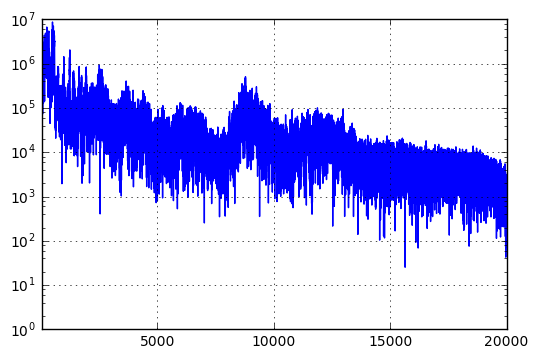

In [23]:
plot(freq, abs(X))
plt.grid()
plt.xlim(20, 20000)
plt.yscale('log')

In [33]:
min(abs(X[20:400]))

73750.958801152286

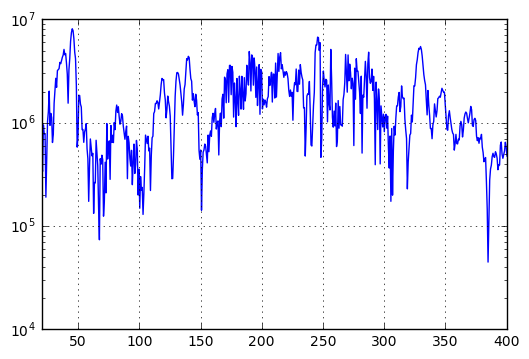

In [36]:
plot(freq, abs(X))
plt.grid()
plt.xlim(20, 400)
plt.ylim(1e4, 1e7)
plt.yscale('log')

In [145]:
#p

In [22]:
import pyaudio

p = pyaudio.PyAudio()

volume = 0.5     # range [0.0, 1.0]
fs = 44100       # sampling rate, Hz, must be integer
duration = 1.0   # in seconds, may be float
f = 440.0        # sine frequency, Hz, may be float

# generate samples, note conversion to float32 array
samples = (np.sin(2*np.pi*np.arange(fs*duration)*f/fs)).astype(np.float32)

# for paFloat32 sample values must be in range [-1.0, 1.0]
stream = p.open(format=pyaudio.paFloat32,
                channels=1,
                rate=fs,
                output=True)

# play. May repeat with different volume values (if done interactively) 
stream.write(volume*samples)

stream.stop_stream()
stream.close()

p.terminate()

In [23]:
p = pyaudio.PyAudio()
n = p.get_device_count()
for i in range(n):
    info = p.get_device_info_by_index(i)
    print(i, info['name'])

0 HDA Intel PCH: ALC293 Analog (hw:0,0)
1 HDA Intel PCH: HDMI 0 (hw:0,3)
2 HDA Intel PCH: HDMI 1 (hw:0,7)
3 HDA Intel PCH: HDMI 2 (hw:0,8)
4 Scarlett Solo USB: Audio (hw:1,0)
5 sysdefault
6 front
7 surround40
8 surround51
9 surround71
10 hdmi
11 pulse
12 dmix
13 default


In [24]:
stream.close()

In [125]:
stream = p.open(
    format=pyaudio.paInt16,
    channels=1,
    rate=fs,
    input=True,
    input_device_index=4,
)

In [126]:
data = stream.read(24000)

In [127]:
x = numpy.fromstring(data, dtype='int16')

In [128]:
x[:10]

array([-2686, -2703, -2538, -2280, -2307, -2345, -2408, -2605, -2643, -2583], dtype=int16)

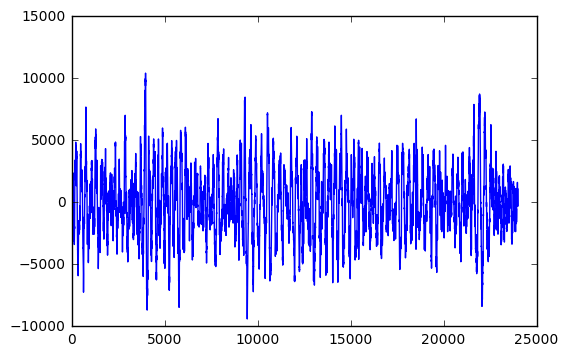

In [129]:
plot(x)

In [133]:
width = 2 ** 16
freq = linspace(0.0, 1.0, width // 2 + 1) * rate / 2.0
x = left[:width]
X = rfft(x)

In [134]:
def dB(amplitude):
    return 20.0 * log10(amplitude)

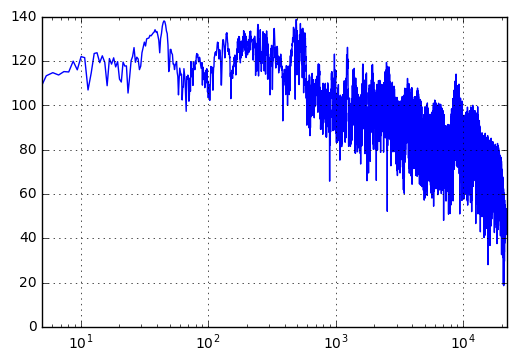

In [143]:
plot(freq, dB(abs(X)))
plt.grid()
plt.xlim(5, 22100)
plt.xscale('log')

In [95]:
import measure

In [100]:
frequencies = logspace(log10(20.0), log10(20000.0), 30)
frequencies = frequencies[10:12]
response, waveforms = measure.scan(frequencies)

44100
216.527346775 24.3469242634
44100
274.764759177 44.5564967866


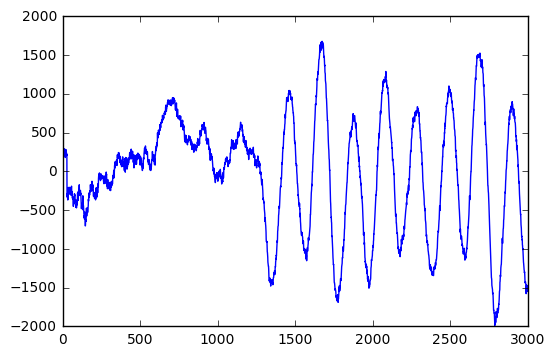

In [101]:
plot(waveforms[0][:3000])

In [69]:
print(waveform)

55.4227547676


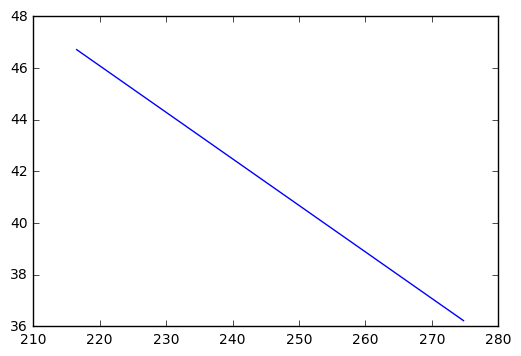

In [66]:
plot(frequencies, response)

In [207]:
import measure
fs = measure.fs

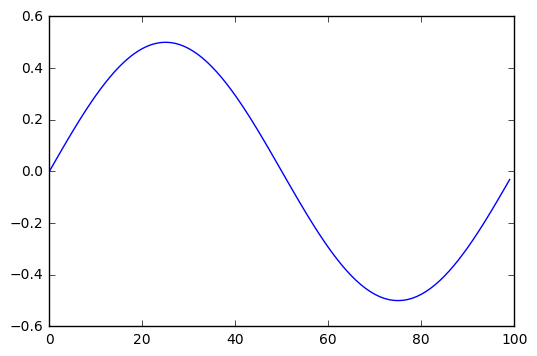

In [208]:
#measure.yeah()
plot(measure.sine_cycle(440.0))

In [308]:
#waveform = measure.sine_cycle(440.0)
waveform, raw_result = measure.yeah() #(waveform, 1.0)

Recording for 10.0 seconds...
Recorded for 16.815942525863647 seconds
Recorded 441,000 samples


NameError: name 'thread' is not defined

In [310]:
44100 * (10.0 / 16.815942525863647)

26225.11341970412

In [293]:
print(44100 * 9.9 / 16.7)
print(44100 / 9.9 * 16.7)

26143.11377245509
74390.90909090907


In [294]:
print('{:,} samples = {} seconds'.format(
    len(raw_result),
    len(raw_result) / fs,
))

441,000 samples = 10.0 seconds


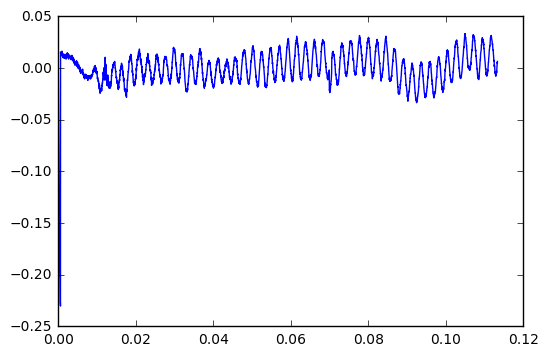

In [295]:
plot(t[:5000], raw_result[:5000])

4374 samples of the waveform captured


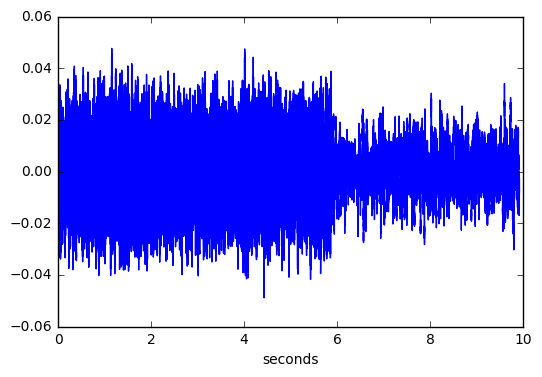

In [296]:
# Trim noise from the beginning.
i = int(measure.fs * 0.08)
result = raw_result[i:]

# Truncate to a whole number of waveforms.
n = len(result) // len(waveform)
i = n * len(waveform)
result = result[:i]

# Compute time scale, and plot.
print(n, 'samples of the waveform captured')
#t = np.linspace(0, seconds, fs * seconds, endpoint=False)
t = np.arange(len(result)) / fs
plot(t, result)
xlabel('seconds')

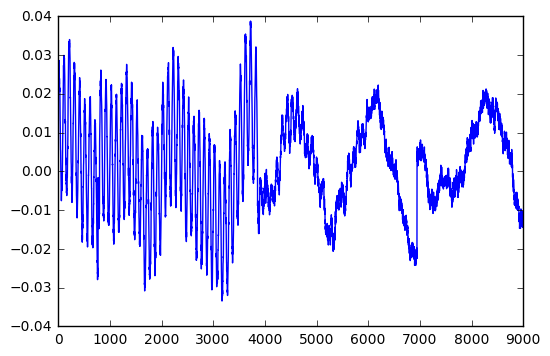

In [297]:
plot(result[255000:264000])

In [268]:
# How much of the recording to skip,
# and how many repeats that leaves us.
#repeats = (len(result) - offset) // len(waveform)
#print('Captured', repeats, 'copies of the waveform')

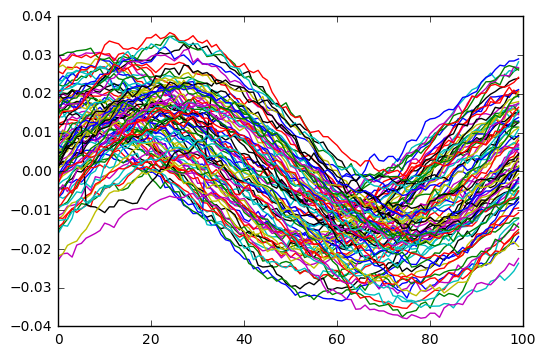

In [301]:
# Show several samples on the same plot.
start = 50
end = start + 90

assert end < len(result)
for i in range(start, end):
    j = i * len(waveform)
    plot(result[j:j+width])

In [299]:
start = int(measure.fs * 0.08)
width = len(waveform)
i0 = 50
i1 = 100
summation = np.zeros(width)
for i in range(start, start + n * width, width):
    summation += result[i:i+width]
print('summed', n, 'instances of the waveform')

ValueError: operands could not be broadcast together with shapes (100,) (72,) (100,) 

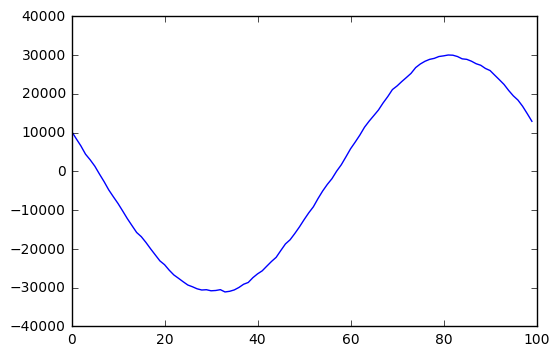

In [232]:
plot(summation)

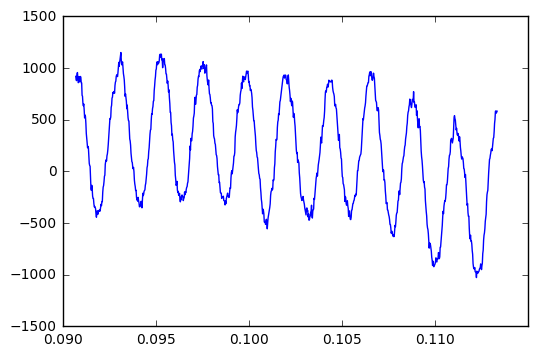

In [215]:
plot(t[4000:5000], result[4000:5000])

In [ ]:
# Old attempt to use "wave", because I was
# ending my arecord sessions with Ctrl-C
# and thus generating a file SciPy could not read:

In [8]:
w = wave.open('/home/brandon/out.wav')

In [9]:
print(w.getnchannels(), 'channels')
print(w.getsampwidth() * 8, 'bits')
print(w.getframerate(), 'Hz')

2 channels
16 bits
44100 Hz


In [10]:
frame_count = w.getnframes()
print(frame_count)
print(frame_count / 44100 / 2)

536870912
6086.97179138322


In [3]:
w = wave.open('/home/brandon/out.wav')
rate = w.getframerate()
frame_count = w.getnframes()
frames = w.readframes(frame_count)
y = numpy.fromstring(frames, dtype='int16').byteswap()

NameError: name 'wave' is not defined

In [157]:
len(y)

428640

In [158]:
#offset_seconds = 6 + 1
#y = y[rate * offset_seconds:]

In [159]:
x = arange(len(y)) / rate
# NOT: linspace(0, len(y) / rate, len(y))

In [ ]:
plot(x, y)

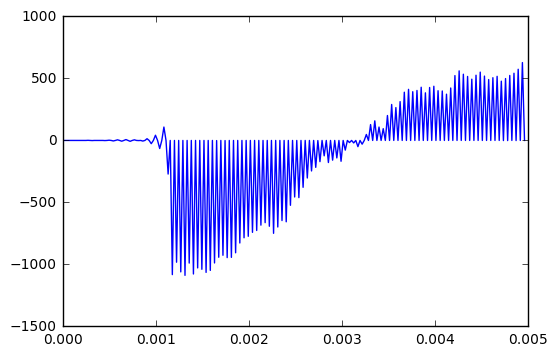

In [155]:
i = int(rate / 20.0)  # period of 20 Hz sinusoid
i = int(rate / 200.0)
plot(x[:i], y[:i])

In [120]:
exponent = int(log2(2 * len(y))) - 1
print(exponent)

19


In [121]:
2 ** exponent

524288

In [122]:
from numpy.fft import fft

In [124]:
print(2 ** 16)
print(2 ** 16 / rate)

65536
1.486077097505669


In [125]:
samples = 2 ** 16
print(samples)
yf = rfft(y[:samples])

65536


In [128]:
#print(len(samples))
print(len(yf))
print(rate)
n = samples // 2 + 1
freq = arange(n) / n * rate / 2.0
print(len(freq))
#plot(freq, yf)

32769
44100
32769


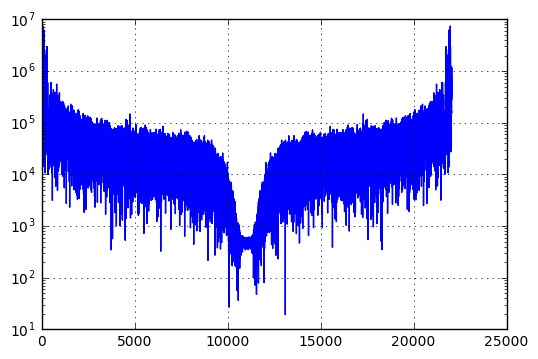

In [129]:
plot(freq, abs(yf))
plt.grid()
#plt.xlim(20, 20000)
plt.yscale('log')